# ADP Technical Tets

In [31]:
!pip install -U pandas scikit-learn transformers[torch] datasets matplotlib seaborn accelerate 

zsh:1: no matches found: transformers[torch]


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

topics_df = pd.read_csv('available_topics.csv')
conv_df = pd.read_csv('available_conversations.csv')

print("--- Available Topics ---")
display(topics_df[['topic_id', 'topic_name']])

--- Available Topics ---


,topic_id,topic_name
0,0,employee_benefits
1,1,employee_training
2,2,other
3,3,payroll
4,4,performance_management
5,5,talent_acquisition
6,6,tax_services
7,7,time_and_attendance


In [ ]:
# Split into 80% training and 20% test set to evaluate the model
train_texts, test_texts, train_labels, test_labels = train_test_split(
    conv_df['message'], 
    conv_df['topic_id'], 
    test_size=0.2, 
    random_state=42,
    stratify=conv_df['topic_id']
)

print(f"Training set size: {len(train_texts)}")
print(f"Test set size: {len(test_texts)}")

Training set size: 1920
Test set size: 480


In [34]:
print("--- Training Baseline Model ---")

# Convert text to numerical features
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf = vectorizer.transform(test_texts)

# Train model (generates a single label per message)
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, train_labels)
baseline_preds = baseline_model.predict(X_test_tfidf)

print("\nClassification Report (Baseline):")
print(classification_report(test_labels, baseline_preds, target_names=topics_df['topic_name'].values))

--- Training Baseline Model ---

Classification Report (Baseline):
                        precision    recall  f1-score   support

     employee_benefits       0.55      0.57      0.56        60
     employee_training       0.39      0.40      0.40        60
                 other       0.42      0.37      0.39        60
               payroll       0.38      0.48      0.42        60
performance_management       0.34      0.43      0.38        60
    talent_acquisition       0.49      0.37      0.42        60
          tax_services       0.48      0.48      0.48        60
   time_and_attendance       0.52      0.40      0.45        60

              accuracy                           0.44       480
             macro avg       0.45      0.44      0.44       480
          weighted avg       0.45      0.44      0.44       480



In [ ]:
print("--- Preparing Fine-Tuning with DistilBERT ---")

import transformers
from transformers import EarlyStoppingCallback

transformers.logging.set_verbosity_error()

model_ckpt = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

train_ds = Dataset.from_dict({"text": train_texts.tolist(), "label": train_labels.tolist()})
test_ds = Dataset.from_dict({"text": test_texts.tolist(), "label": test_labels.tolist()})

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_test = test_ds.map(tokenize_function, batched=True)

# Load pre-trained model
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=8)

num_train_epochs = 20

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=num_train_epochs,
    weight_decay=0.01,
    logging_steps=10,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    dataloader_pin_memory=False  
)

class ReduceLROnPlateauCallback(EarlyStoppingCallback):
    """
    Reduce learning rate when loss does not improve.
    """
    def __init__(self, patience=2, factor=0.5, min_lr=1e-7):
        super().__init__(early_stopping_patience=patience) 
        self.factor = factor
        self.min_lr = min_lr
        self.best = float("inf")
        self.wait = 0

    def on_evaluate(self, args, state, control, **kwargs):
        logs = kwargs.get("metrics", {})
        eval_loss = logs.get("eval_loss")
        
        optimizer = kwargs.get('optimizer', None)
        
        if eval_loss is not None:
            if eval_loss < self.best - 1e-4:  
                self.best = eval_loss
                self.wait = 0
            else:
                self.wait += 1
                
            if self.wait >= self.early_stopping_patience and control.should_training_stop is False:
                if optimizer is not None:
                    lr = optimizer.param_groups[0]['lr']
                    new_lr = max(lr * self.factor, self.min_lr)
                    if lr > self.min_lr:
                        optimizer.param_groups[0]['lr'] = new_lr
                        print(f"\nReducing learning rate to {new_lr:.5g}")
                self.wait = 0  

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    # You can use only your custom callback since it inherits from EarlyStoppingCallback
    callbacks=[ReduceLROnPlateauCallback(patience=3, factor=0.5, min_lr=1e-7)] 
)

# Start training
trainer.train()

--- Preparando Fine-Tuning con DistilBERT ---


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7413.84it/s]


{'loss': '2.086', 'grad_norm': '2.247', 'learning_rate': '1.992e-05', 'epoch': '0.08333'}
{'loss': '2.066', 'grad_norm': '1.606', 'learning_rate': '1.984e-05', 'epoch': '0.1667'}
{'loss': '2.055', 'grad_norm': '1.628', 'learning_rate': '1.976e-05', 'epoch': '0.25'}
{'loss': '2.073', 'grad_norm': '2.2', 'learning_rate': '1.968e-05', 'epoch': '0.3333'}
{'loss': '2.059', 'grad_norm': '2.085', 'learning_rate': '1.959e-05', 'epoch': '0.4167'}
{'loss': '2.055', 'grad_norm': '2.784', 'learning_rate': '1.951e-05', 'epoch': '0.5'}
{'loss': '1.984', 'grad_norm': '3.464', 'learning_rate': '1.943e-05', 'epoch': '0.5833'}
{'loss': '1.971', 'grad_norm': '3.183', 'learning_rate': '1.934e-05', 'epoch': '0.6667'}
{'loss': '1.91', 'grad_norm': '4.343', 'learning_rate': '1.926e-05', 'epoch': '0.75'}
{'loss': '1.883', 'grad_norm': '4.235', 'learning_rate': '1.918e-05', 'epoch': '0.8333'}
{'loss': '1.835', 'grad_norm': '4.326', 'learning_rate': '1.909e-05', 'epoch': '0.9167'}
{'loss': '1.812', 'grad_norm':

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.19it/s]


{'loss': '1.737', 'grad_norm': '4.626', 'learning_rate': '1.893e-05', 'epoch': '1.083'}
{'loss': '1.706', 'grad_norm': '5.494', 'learning_rate': '1.884e-05', 'epoch': '1.167'}
{'loss': '1.72', 'grad_norm': '4.169', 'learning_rate': '1.876e-05', 'epoch': '1.25'}
{'loss': '1.625', 'grad_norm': '5.845', 'learning_rate': '1.867e-05', 'epoch': '1.333'}
{'loss': '1.585', 'grad_norm': '5.045', 'learning_rate': '1.859e-05', 'epoch': '1.417'}
{'loss': '1.678', 'grad_norm': '5.056', 'learning_rate': '1.851e-05', 'epoch': '1.5'}
{'loss': '1.659', 'grad_norm': '5.039', 'learning_rate': '1.843e-05', 'epoch': '1.583'}
{'loss': '1.53', 'grad_norm': '6.652', 'learning_rate': '1.834e-05', 'epoch': '1.667'}
{'loss': '1.555', 'grad_norm': '5.896', 'learning_rate': '1.826e-05', 'epoch': '1.75'}
{'loss': '1.503', 'grad_norm': '6.513', 'learning_rate': '1.818e-05', 'epoch': '1.833'}
{'loss': '1.519', 'grad_norm': '6.096', 'learning_rate': '1.809e-05', 'epoch': '1.917'}
{'loss': '1.552', 'grad_norm': '6.263'

...

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.50s/it]


{'loss': '0.004391', 'grad_norm': '0.6746', 'learning_rate': '9.25e-07', 'epoch': '19.08'}
{'loss': '0.004187', 'grad_norm': '0.1115', 'learning_rate': '8.417e-07', 'epoch': '19.17'}
{'loss': '0.00442', 'grad_norm': '0.187', 'learning_rate': '7.583e-07', 'epoch': '19.25'}
{'loss': '0.00428', 'grad_norm': '0.1623', 'learning_rate': '6.75e-07', 'epoch': '19.33'}
{'loss': '0.009847', 'grad_norm': '0.07528', 'learning_rate': '5.917e-07', 'epoch': '19.42'}
{'loss': '0.004545', 'grad_norm': '0.514', 'learning_rate': '5.083e-07', 'epoch': '19.5'}
{'loss': '0.03641', 'grad_norm': '0.08934', 'learning_rate': '4.25e-07', 'epoch': '19.58'}
{'loss': '0.02154', 'grad_norm': '0.1012', 'learning_rate': '3.417e-07', 'epoch': '19.67'}
{'loss': '0.006885', 'grad_norm': '0.06717', 'learning_rate': '2.583e-07', 'epoch': '19.75'}
{'loss': '0.005001', 'grad_norm': '0.1089', 'learning_rate': '1.75e-07', 'epoch': '19.83'}
{'loss': '0.04224', 'grad_norm': '6.478', 'learning_rate': '9.167e-08', 'epoch': '19.92'

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.71it/s]


{'train_runtime': '3474', 'train_samples_per_second': '11.05', 'train_steps_per_second': '0.691', 'train_loss': '0.4173', 'epoch': '20'}


TrainOutput(global_step=2400, training_loss=0.4173398937378079, metrics={'train_runtime': 3474.0485, 'train_samples_per_second': 11.053, 'train_steps_per_second': 0.691, 'train_loss': 0.4173398937378079, 'epoch': 20.0})


Classification Report (DistilBERT):
                        precision    recall  f1-score   support

     employee_benefits       0.70      0.65      0.67        60
     employee_training       0.57      0.72      0.64        60
                 other       0.57      0.47      0.51        60
               payroll       0.58      0.75      0.65        60
performance_management       0.64      0.57      0.60        60
    talent_acquisition       0.63      0.65      0.64        60
          tax_services       0.75      0.78      0.76        60
   time_and_attendance       0.82      0.60      0.69        60

              accuracy                           0.65       480
             macro avg       0.66      0.65      0.65       480
          weighted avg       0.66      0.65      0.65       480



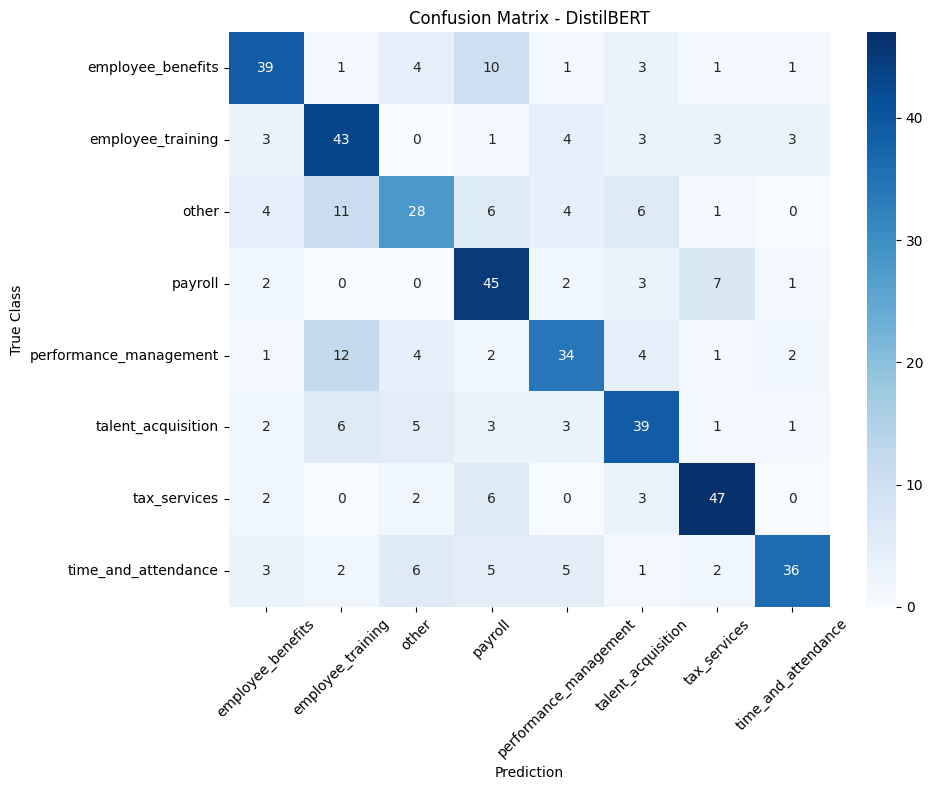

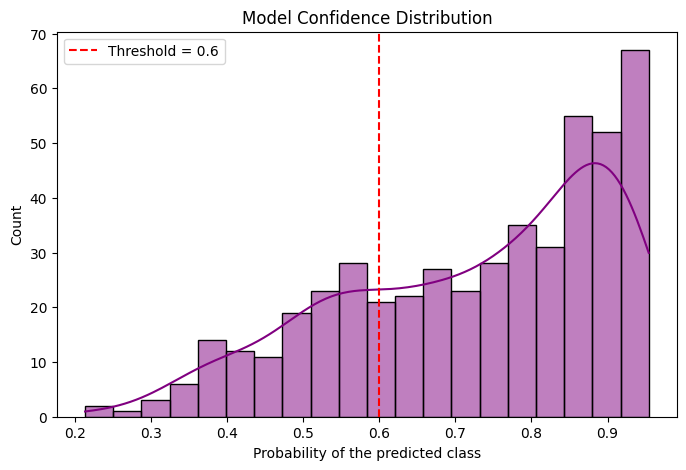

In [35]:
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=-1)
probs = torch.nn.functional.softmax(torch.tensor(predictions.predictions), dim=-1).numpy()

print("\nClassification Report (DistilBERT):")
print(classification_report(test_labels, preds, target_names=topics_df['topic_name'].values))

# --- Plot: Confusion Matrix ---
cm = confusion_matrix(test_labels, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=topics_df['topic_name'].values,
            yticklabels=topics_df['topic_name'].values)
plt.title('Confusion Matrix - DistilBERT')
plt.xlabel('Prediction')
plt.ylabel('True Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --- Plot: Confidence Distribution ---
probs_max = probs.max(axis=1)
plt.figure(figsize=(8, 5))
sns.histplot(probs_max, bins=20, kde=True, color='purple')
plt.axvline(x=0.6, color='red', linestyle='--', label='Threshold = 0.6')
plt.title('Model Confidence Distribution')
plt.xlabel('Probability of the predicted class')
plt.legend()
plt.show()

In [36]:
def classify_message(text, threshold=0.6):
    """
    Classifies the message and flags it if unsupported [cite: 14].
    Ensures at most one topic per message [cite: 15].
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    max_prob, predicted_idx = torch.max(probs, dim=1)
    
    # If the confidence is below the threshold, flag as unsupported [cite: 14]
    if max_prob.item() < threshold:
        return "FLAG: Unsupported operation (Low confidence)"
    
    return topics_df.iloc[predicted_idx.item()]['topic_name']

# Tests
print("Test 1 (Supported):", classify_message("How do I request time off for a medical appointment?"))
print("Test 2 (Unsupported):", classify_message("Can you help me fix the printer in the hallway?"))

Test 1 (Supported): FLAG: Unsupported operation (Low confidence)
Test 2 (Unsupported): other


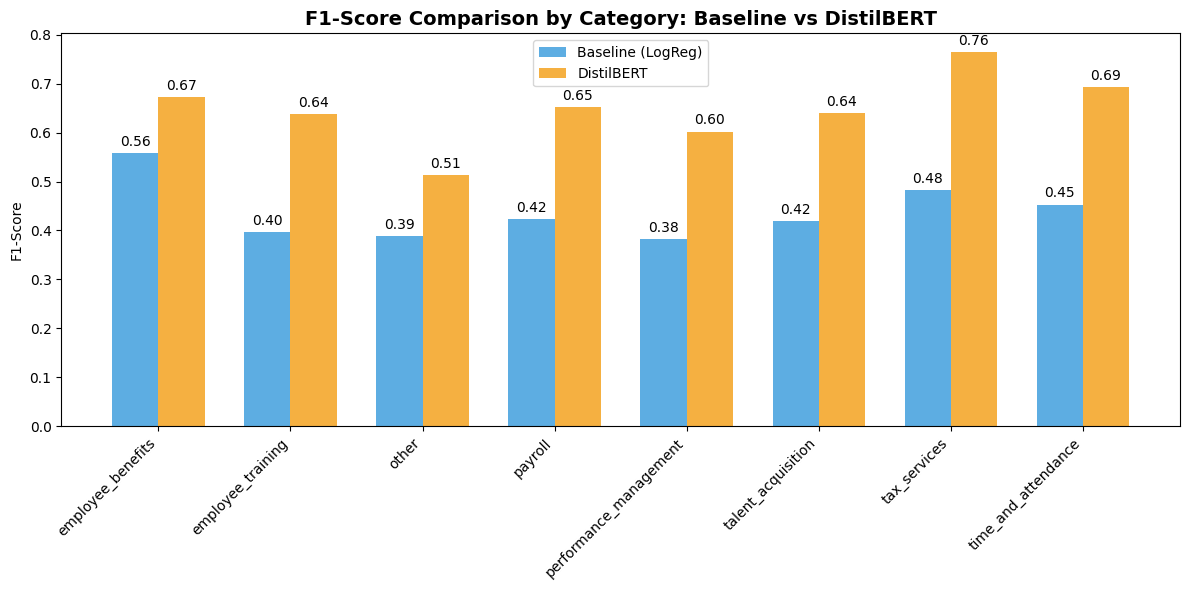

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report

# 1. Extract reports as dictionaries
base_report = classification_report(test_labels, baseline_preds, output_dict=True)
distil_report = classification_report(test_labels, preds, output_dict=True)

# 2. Label names (0 to 7)
labels = topics_df['topic_name'].tolist()

# 3. Dynamically extract F1-scores for each category (keys are '0', '1', '2', ...)
baseline_f1 = [base_report[str(i)]['f1-score'] for i in range(8)]
distilbert_f1 = [distil_report[str(i)]['f1-score'] for i in range(8)]

# Plot configuration
x = np.arange(len(labels))
width = 0.35

# ==========================================================
# Plot 1: F1-Score Comparison by Category
# ==========================================================
fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, baseline_f1, width, label='Baseline (LogReg)', color='#5DADE2')
rects2 = ax.bar(x + width/2, distilbert_f1, width, label='DistilBERT', color='#F5B041')

ax.set_ylabel('F1-Score')
ax.set_title('F1-Score Comparison by Category: Baseline vs DistilBERT', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.legend()

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')

fig.tight_layout()
plt.savefig('category_comparison.png')
plt.show()

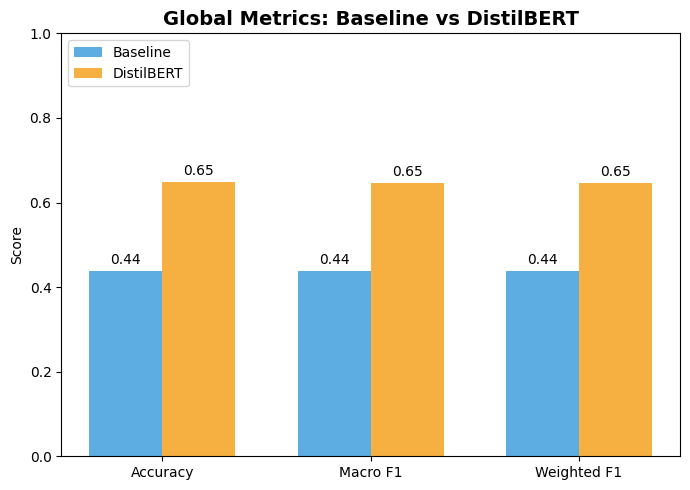

In [38]:
# ==========================================================
# Plot 2: Global Metrics Comparison
# ==========================================================
# Dynamically extract global metrics
base_overall = [base_report['accuracy'], base_report['macro avg']['f1-score'], base_report['weighted avg']['f1-score']]
dist_overall = [distil_report['accuracy'], distil_report['macro avg']['f1-score'], distil_report['weighted avg']['f1-score']]

overall_labels = ['Accuracy', 'Macro F1', 'Weighted F1']
fig2, ax2 = plt.subplots(figsize=(7, 5))
x2 = np.arange(len(overall_labels))

rects_base = ax2.bar(x2 - width/2, base_overall, width, label='Baseline', color='#5DADE2')
rects_dist = ax2.bar(x2 + width/2, dist_overall, width, label='DistilBERT', color='#F5B041')

ax2.set_ylabel('Score')
ax2.set_title('Global Metrics: Baseline vs DistilBERT', fontsize=14, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(overall_labels)
ax2.set_ylim(0, 1.0)
ax2.legend(loc='upper left')

ax2.bar_label(rects_base, padding=3, fmt='%.2f')
ax2.bar_label(rects_dist, padding=3, fmt='%.2f')

fig2.tight_layout()
plt.savefig('global_comparison.png')
plt.show()